<a href="https://colab.research.google.com/github/europecodingschool/ECS---VB---YZ---08.26/blob/main/VB_YZ_Ders_16_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
veri = pd.read_csv("/content/ucak_bileti.csv")

In [3]:
veri.head()

,rota,havayolu,aktarma,ucus_suresi_dk,kalan_gun,kalkis_dilimi,ucus_gunu,bayram_donemi,bagaj_dahil,doluluk_orani,arama_cihazi,fiyat_tl
0,ANK-IZM,Kanat,0,72,3,Ogle,Cuma,0,0,0.90,Mobil,4310
1,IST-ANT,Bulut,0,85,65,Aksam,Hafta ici,0,1,0.71,Mobil,2740
2,IZM-ANT,Zirve,0,61,19,Sabah,Pazar,0,1,0.61,Masaustu,2790
3,IST-VAN,Zirve,0,136,64,Sabah,Hafta ici,1,0,0.54,Masaustu,6050
4,IST-ANK,Kanat,0,77,51,Ogle,Hafta ici,0,0,0.45,Mobil,1390


Senaryomuz ve hedef:
**kalın metin**

Alacağın bu bilet pahalı mı ucuz mu ve olması gereken fiyatını tahmin etme yoluna gidebiliriz.


In [4]:
veri.shape

(2500, 12)

In [5]:
veri.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   rota            2500 non-null   object 
 1   havayolu        2500 non-null   object 
 2   aktarma         2500 non-null   int64  
 3   ucus_suresi_dk  2500 non-null   int64  
 4   kalan_gun       2500 non-null   int64  
 5   kalkis_dilimi   2500 non-null   object 
 6   ucus_gunu       2500 non-null   object 
 7   bayram_donemi   2500 non-null   int64  
 8   bagaj_dahil     2500 non-null   int64  
 9   doluluk_orani   2500 non-null   float64
 10  arama_cihazi    2500 non-null   object 
 11  fiyat_tl        2500 non-null   int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 234.5+ KB


In [6]:
veri.isnull().sum()

,0
rota,0
havayolu,0
aktarma,0
ucus_suresi_dk,0
kalan_gun,0
kalkis_dilimi,0
ucus_gunu,0
bayram_donemi,0
bagaj_dahil,0
doluluk_orani,0


In [7]:
veri.describe().round(2)

,aktarma,ucus_suresi_dk,kalan_gun,bayram_donemi,bagaj_dahil,doluluk_orani,fiyat_tl
count,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00
mean,0.19,106.62,45.33,0.08,0.47,0.66,2440.22
std,0.39,60.10,26.23,0.27,0.50,0.16,1048.97
min,0.00,55.00,0.00,0.00,0.00,0.20,910.00
25%,0.00,69.00,22.00,0.00,0.00,0.55,1770.00
50%,0.00,79.00,46.00,0.00,0.00,0.68,2200.00
75%,0.00,116.00,68.00,0.00,1.00,0.79,2800.00
max,1.00,334.00,90.00,1.00,1.00,0.98,13430.00


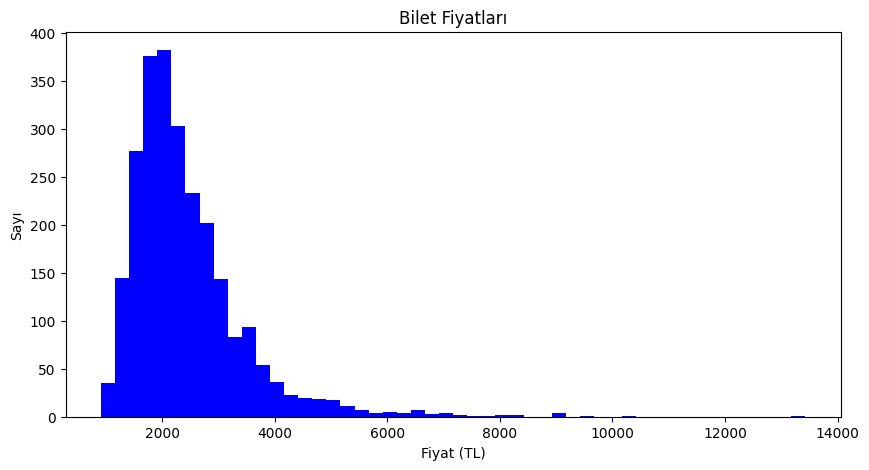

In [8]:
#Bilet fiyatlarının dağılımı histogram.

plt.figure(figsize=(10,5))
plt.hist(veri["fiyat_tl"], bins=50, color="b")
plt.title("Bilet Fiyatları")
plt.xlabel("Fiyat (TL)")
plt.ylabel("Sayı")
plt.show()


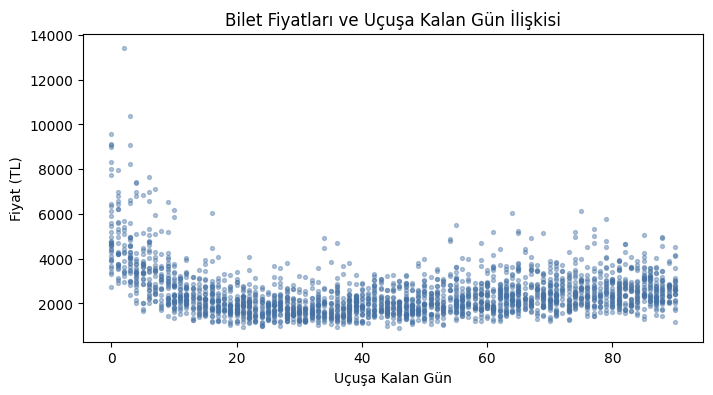

In [9]:
# UÇAŞA KALAN GÜN ve FİYAT İLİŞKİSİ

plt.figure(figsize=(8,4))
plt.scatter(veri["kalan_gun"], veri["fiyat_tl"], color="#4671A3", s=8, alpha=0.4)
plt.title("Bilet Fiyatları ve Uçuşa Kalan Gün İlişkisi")
plt.xlabel("Uçuşa Kalan Gün")
plt.ylabel("Fiyat (TL)")
plt.show()

In [10]:
havayolu_ortalama = veri.groupby("havayolu")["fiyat_tl"].mean().round(0)
print(havayolu_ortalama)

havayolu
Bulut    2368.0
Kanat    2160.0
Zirve    3032.0
Name: fiyat_tl, dtype: float64


In [11]:
rota_ortalama = veri.groupby("rota")["fiyat_tl"].mean().round(0)
print(rota_ortalama)

rota
ANK-IZM    2370.0
ANK-TZX    2383.0
IST-ANK    2310.0
IST-ANT    2417.0
IST-IZM    2292.0
IST-TZX    2802.0
IST-VAN    3141.0
IZM-ANT    2443.0
Name: fiyat_tl, dtype: float64


In [12]:
bayram_ortalama = veri.groupby("bayram_donemi")["fiyat_tl"].mean().round(0)
print(bayram_ortalama)
#

bayram_donemi
0    2320.0
1    3874.0
Name: fiyat_tl, dtype: float64


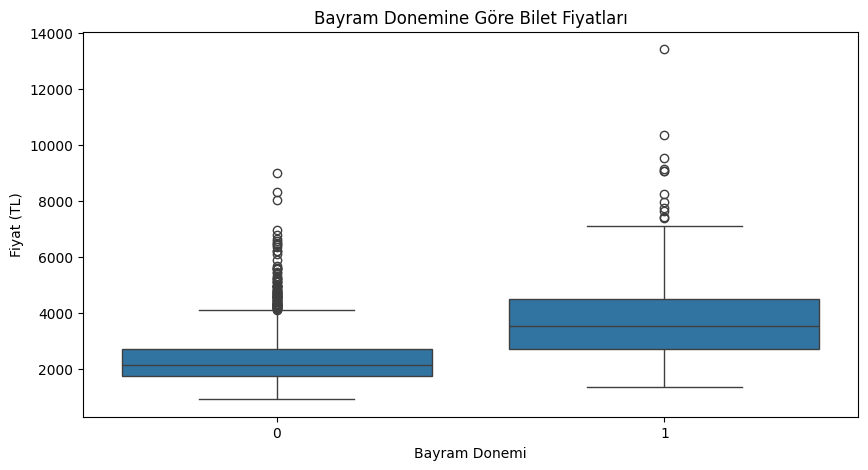

In [13]:
plt.figure(figsize=(10,5))
sns.boxplot(data=veri, x="bayram_donemi", y="fiyat_tl")
plt.title("Bayram Donemine Göre Bilet Fiyatları")
plt.xlabel("Bayram Donemi")
plt.ylabel("Fiyat (TL)")
plt.show()

In [14]:
# kalkış dilimine göre fiyat ortalamaları
dilim_ortalama = veri.groupby("kalkis_dilimi")["fiyat_tl"].mean().round(0)
dilim_ortalama = dilim_ortalama.sort_values()
print(dilim_ortalama)

kalkis_dilimi
Gece           1996.0
Sabah erken    2241.0
Ogle           2348.0
Sabah          2576.0
Aksam          2722.0
Name: fiyat_tl, dtype: float64


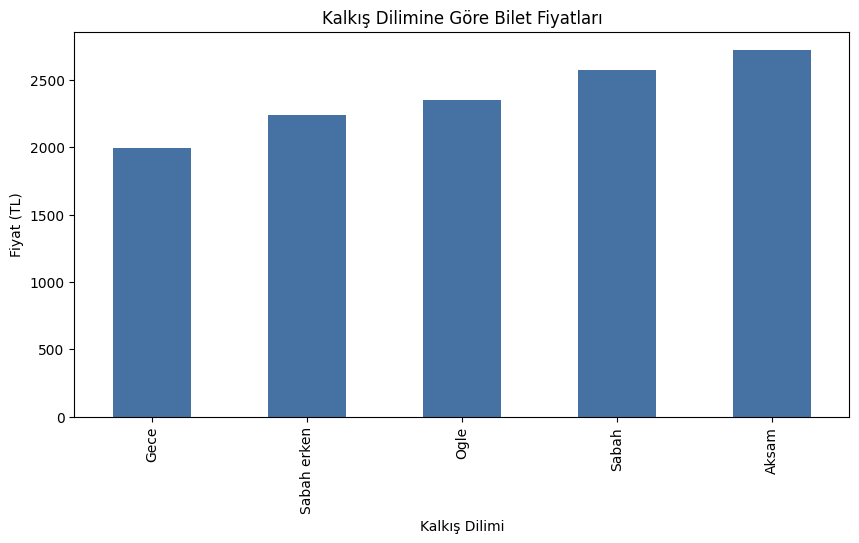

In [15]:
plt.figure(figsize=(10,5))
dilim_ortalama.plot(kind="bar", color="#4671A3")
plt.title("Kalkış Dilimine Göre Bilet Fiyatları")
plt.xlabel("Kalkış Dilimi")
plt.ylabel("Fiyat (TL)")
plt.show()

In [16]:
veri.groupby("arama_cihazi")["fiyat_tl"].mean().round(0)

,fiyat_tl
arama_cihazi,
Masaustu,2422.0
Mobil,2450.0


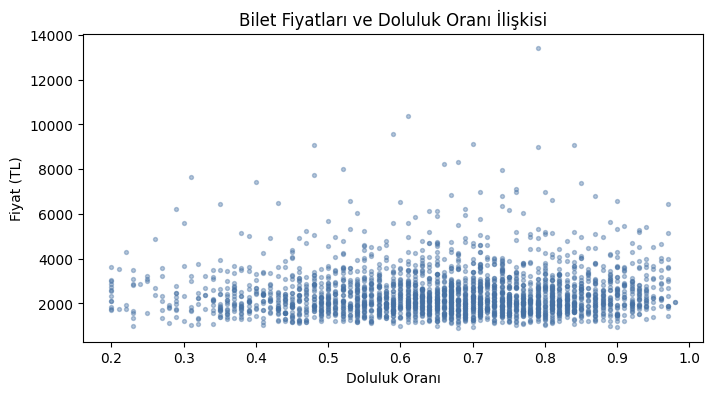

In [17]:
plt.figure(figsize=(8,4))
plt.scatter(veri["doluluk_orani"], veri["fiyat_tl"], color="#4671A3", s=8, alpha=0.4)
plt.title("Bilet Fiyatları ve Doluluk Oranı İlişkisi")
plt.xlabel("Doluluk Oranı")
plt.ylabel("Fiyat (TL)")
plt.show() # grafikte belirgin bir desen yok. Doluluk oranı artıkça veya azaldıkça fiyatta bir değişm var demek doğru olmaz.

In [18]:
veri.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   rota            2500 non-null   object 
 1   havayolu        2500 non-null   object 
 2   aktarma         2500 non-null   int64  
 3   ucus_suresi_dk  2500 non-null   int64  
 4   kalan_gun       2500 non-null   int64  
 5   kalkis_dilimi   2500 non-null   object 
 6   ucus_gunu       2500 non-null   object 
 7   bayram_donemi   2500 non-null   int64  
 8   bagaj_dahil     2500 non-null   int64  
 9   doluluk_orani   2500 non-null   float64
 10  arama_cihazi    2500 non-null   object 
 11  fiyat_tl        2500 non-null   int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 234.5+ KB


In [19]:
# MODELE HAZIRLIK

veri = pd.get_dummies(veri, columns=["havayolu", "rota", "kalkis_dilimi", "arama_cihazi","ucus_gunu"])

X = veri.drop(columns=["fiyat_tl"])
y = veri["fiyat_tl"]

print(X.shape)
print(X.columns.tolist())

#

(2500, 28)
['aktarma', 'ucus_suresi_dk', 'kalan_gun', 'bayram_donemi', 'bagaj_dahil', 'doluluk_orani', 'havayolu_Bulut', 'havayolu_Kanat', 'havayolu_Zirve', 'rota_ANK-IZM', 'rota_ANK-TZX', 'rota_IST-ANK', 'rota_IST-ANT', 'rota_IST-IZM', 'rota_IST-TZX', 'rota_IST-VAN', 'rota_IZM-ANT', 'kalkis_dilimi_Aksam', 'kalkis_dilimi_Gece', 'kalkis_dilimi_Ogle', 'kalkis_dilimi_Sabah', 'kalkis_dilimi_Sabah erken', 'arama_cihazi_Masaustu', 'arama_cihazi_Mobil', 'ucus_gunu_Cuma', 'ucus_gunu_Cumartesi', 'ucus_gunu_Hafta ici', 'ucus_gunu_Pazar']


In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Eğitim:", X_train.shape, y_train.shape)
print("Test:", X_test.shape, y_test.shape)

Eğitim: (2000, 28) (2000,)
Test: (500, 28) (500,)


In [21]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error

# Baz referans değer bakıyoruz. Algoritmamızın seviyesini ölçmek adına.

ortalama_tahmin = np.full(len(y_test), y_train.mean())

print("Ortalama Tahmin RMSE:", np.sqrt(mean_squared_error(y_test, ortalama_tahmin)))
print("Ortalama Tahmin MAE:", mean_absolute_error(y_test, ortalama_tahmin))
print("Ortalama Tahmin MAPE:", mean_absolute_percentage_error(y_test, ortalama_tahmin))
#




Ortalama Tahmin RMSE: 1069.0482303432339
Ortalama Tahmin MAE: 738.1351200000001
Ortalama Tahmin MAPE: 0.3266767714627545


In [22]:
# yaklaşık %33 yanılıyoruz. ortalama fiyatla tahin etsek.

In [25]:
from sklearn.linear_model import LinearRegression
#Doğrusal Lineer regresyon Uygulaması

lineer = LinearRegression()
lineer.fit(X_train, y_train)
lineer_tahmin = lineer.predict(X_test)

print("DOĞRUSAL REGRESYON")
print("R2:",r2_score(y_test, lineer_tahmin))
print("MAE:", mean_absolute_error(y_test, lineer_tahmin))
print("MAPE:", mean_absolute_percentage_error(y_test, lineer_tahmin))

DOĞRUSAL REGRESYON
R2: 0.4868068860933703
MAE: 521.1604806292958
MAPE: 0.21504843525657025


In [29]:
#Tek Karar Ağacı

from sklearn.tree import DecisionTreeRegressor

agac = DecisionTreeRegressor()
agac.fit(X_train, y_train)
agac_tahmin = agac.predict(X_test)

print("TEK KARAR AĞACI")
print("Eğitim R2:", r2_score(y_train, agac.predict(X_train)))
print("R2:",r2_score(y_test, agac_tahmin))
print("MAE:", mean_absolute_error(y_test, agac_tahmin))
print("MAPE:", mean_absolute_percentage_error(y_test, agac_tahmin))


TEK KARAR AĞACI
Eğitim R2: 1.0
R2: 0.6841522436400014
MAE: 359.04
MAPE: 0.14195446303479076


In [31]:
# Gradient Boosting

from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(random_state=42)
gb.fit(X_train, y_train)
gb_tahmin = gb.predict(X_test)

print("GRADIENT BOOSTING (varsayılan tur: 100, learning rate=0.1, max_depth=3)")
print("Eğitim R2:", r2_score(y_train, gb.predict(X_train)))
print("R2:",r2_score(y_test, gb_tahmin))
print("MAE:", mean_absolute_error(y_test, gb_tahmin))
print("MAPE:", mean_absolute_percentage_error(y_test, gb_tahmin))
#

GRADIENT BOOSTING (varsayılan tur: 100, learning rate=0.1, max_depth=3)
Eğitim R2: 0.9644936223457425
R2: 0.9310036676318579
MAE: 181.71490196485288
MAPE: 0.07213301647040231


In [34]:
# Gradient Boosting Parametre - 1 (learning rate oranı değiştirelim. Öğrenme oranı)

gb_hizli = GradientBoostingRegressor(random_state=42, learning_rate=1.0)
gb_hizli.fit(X_train, y_train)

gb_orta = GradientBoostingRegressor(random_state=42, learning_rate=0.1)
gb_orta.fit(X_train, y_train)

gb_yavas = GradientBoostingRegressor(random_state=42, learning_rate=0.01)
gb_yavas.fit(X_train, y_train)

print("GRADIENT BOOSTING (learning rate=1.0)")
print("Eğitim R2:", r2_score(y_train, gb_hizli.predict(X_train)))
print("Test R2:", r2_score(y_test, gb_hizli.predict(X_test)))
print("**************")
print("GRADIENT BOOSTING (learning rate=0.1)")
print("Eğitim R2:", r2_score(y_train, gb_orta.predict(X_train)))
print("Test R2:", r2_score(y_test, gb_orta.predict(X_test)))
print("**************")
print("GRADIENT BOOSTING (learning rate=0.01)")
print("Eğitim R2:", r2_score(y_train, gb_yavas.predict(X_train)))
print("Test R2:", r2_score(y_test,gb_yavas.predict(X_test)))

GRADIENT BOOSTING (learning rate=1.0)
Eğitim R2: 0.9841684437165316
Test R2: 0.8984576329370818
**************
GRADIENT BOOSTING (learning rate=0.1)
Eğitim R2: 0.9644936223457425
Test R2: 0.9310036676318579
**************
GRADIENT BOOSTING (learning rate=0.01)
Eğitim R2: 0.5727228046688506
Test R2: 0.5200145744040758


In [36]:
# Gradient Boosting Parametre - 2 (learning rate ve Tur Sayısı Birlikte)

gb_yavas_uzun = GradientBoostingRegressor(random_state=42, learning_rate=0.01, n_estimators=1000)
gb_yavas_uzun.fit(X_train, y_train)

gb_orta_uzun = GradientBoostingRegressor(random_state=42, learning_rate=0.1, n_estimators=1000)
gb_orta_uzun.fit(X_train, y_train)

gb_hizli_uzun = GradientBoostingRegressor(random_state=42, learning_rate=1.0, n_estimators=1000)
gb_hizli_uzun.fit(X_train, y_train)

print("GRADIENT BOOSTING (learning rate=0.01, n_estimators=1000)")
print("Eğitim R2:", r2_score(y_train, gb_yavas_uzun.predict(X_train)))
print("Test R2:", r2_score(y_test, gb_yavas_uzun.predict(X_test)))

print("**************")

print("GRADIENT BOOSTING (learning rate=0.1, n_estimators=1000)")
print("Eğitim R2:", r2_score(y_train, gb_orta_uzun.predict(X_train)))
print("Test R2:", r2_score(y_test, gb_orta_uzun.predict(X_test)))

print("**************")

print("GRADIENT BOOSTING (learning rate=1.0, n_estimators=1000)")
print("Eğitim R2:", r2_score(y_train, gb_hizli_uzun.predict(X_train)))
print("Test R2:", r2_score(y_test, gb_hizli_uzun.predict(X_test)))


GRADIENT BOOSTING (learning rate=0.01, n_estimators=1000)
Eğitim R2: 0.9628781819451259
Test R2: 0.9278024531330138
**************
GRADIENT BOOSTING (learning rate=0.1, n_estimators=1000)
Eğitim R2: 0.9916908783130315
Test R2: 0.9552445151779733
**************
GRADIENT BOOSTING (learning rate=1.0, n_estimators=1000)
Eğitim R2: 0.9996340583762555
Test R2: 0.892102667150569


In [38]:
# # Gradient Boosting Parametre - 2 (learning rate ve Tur Sayısı Birlikte - n_estimator ile oynayacağız)

gb_orta_500 = GradientBoostingRegressor(random_state=42, learning_rate=0.1, n_estimators=500)
gb_orta_500.fit(X_train, y_train)

print("GRADIENT BOOSTING (learning rate=0.1, n_estimators=500)")
print("Eğitim R2:", r2_score(y_train, gb_orta_500.predict(X_train)))
print("Test R2:", r2_score(y_test, gb_orta_500.predict(X_test)))

GRADIENT BOOSTING (learning rate=0.1, n_estimators=500)
Eğitim R2: 0.9868452533986595
Test R2: 0.9540924000281847


In [49]:
# SON MODEL (n_estimator=500, learning_rate=0.1 olarak ve max_depth=3)

son_model = gb_orta_500
son_tahmin = son_model.predict(X_test)

print("SON MODEL:n_estimator=500, learning_rate=0.1 olarak ve max_depth=3 ")
print("Eğitim R2:", r2_score(y_train, son_model.predict(X_train)))
print("Test R2:", r2_score(y_test, son_tahmin))
print("MAE:", mean_absolute_error(y_test, son_tahmin))
print("MAPE:", mean_absolute_percentage_error(y_test, son_tahmin))
#

SON MODEL:n_estimator=500, learning_rate=0.1 olarak ve max_depth=3 
Eğitim R2: 0.9868452533986595
Test R2: 0.9540924000281847
MAE: 146.52788000590704
MAPE: 0.059167266718764176


In [52]:
onem = pd.Series(son_model.feature_importances_, index=X_train.columns)
onem = onem.sort_values(ascending=False)
print(onem)
#Hangi değişken ne kadar önemli karar sürecinde.

kalan_gun                    0.469443
bayram_donemi                0.180476
havayolu_Zirve               0.099087
ucus_suresi_dk               0.040580
kalkis_dilimi_Gece           0.032166
bagaj_dahil                  0.031418
aktarma                      0.030473
havayolu_Kanat               0.015204
ucus_gunu_Hafta ici          0.015106
kalkis_dilimi_Aksam          0.014602
doluluk_orani                0.013277
kalkis_dilimi_Sabah          0.013098
rota_IST-VAN                 0.012512
kalkis_dilimi_Sabah erken    0.006607
ucus_gunu_Pazar              0.005793
ucus_gunu_Cumartesi          0.005406
ucus_gunu_Cuma               0.004749
rota_IST-TZX                 0.004423
rota_IZM-ANT                 0.001200
rota_IST-IZM                 0.001097
rota_ANK-IZM                 0.000762
kalkis_dilimi_Ogle           0.000660
arama_cihazi_Masaustu        0.000527
rota_IST-ANT                 0.000488
rota_ANK-TZX                 0.000455
arama_cihazi_Mobil           0.000142
rota_IST-ANK

In [48]:
bilet = X_test.head(1).copy()
print(bilet.T)
print("Gerçek fiyat:", y_test.head(1).values[0])
print("Tahmin edilen fiyat:", son_model.predict(bilet)[0])

#
#

                            1447
aktarma                        0
ucus_suresi_dk                76
kalan_gun                     15
bayram_donemi                  0
bagaj_dahil                    0
doluluk_orani               0.71
havayolu_Bulut             False
havayolu_Kanat              True
havayolu_Zirve             False
rota_ANK-IZM               False
rota_ANK-TZX               False
rota_IST-ANK               False
rota_IST-ANT                True
rota_IST-IZM               False
rota_IST-TZX               False
rota_IST-VAN               False
rota_IZM-ANT               False
kalkis_dilimi_Aksam         True
kalkis_dilimi_Gece         False
kalkis_dilimi_Ogle         False
kalkis_dilimi_Sabah        False
kalkis_dilimi_Sabah erken  False
arama_cihazi_Masaustu      False
arama_cihazi_Mobil          True
ucus_gunu_Cuma             False
ucus_gunu_Cumartesi        False
ucus_gunu_Hafta ici         True
ucus_gunu_Pazar            False
Gerçek fiyat: 1960
Tahmin edilen fiyat: 197

In [51]:
# bu bileti 30 gün kala alsaydık fiyatı ne olurdu. # bu bileti son dakika 1 gün kala alsak ne olurdu?

bilet_erken = bilet.copy()
bilet_erken["kalan_gun"] = 30
print(son_model.predict(bilet_erken)[0])
#

bilet_son_dk = bilet.copy()
bilet_son_dk["kalan_gun"] = 1
print(son_model.predict(bilet_son_dk)[0])

1567.221317716499
4302.961618447093


**Gerçek fiyatı 1960 TL olan bileti algoritmamız 1971 TL olarak tahmin ediyor. Eğer bu bileti 15 gün değil 30 gün kala alsaydık algoritmamıza göre 1567 TL den alacaktık. Eğer 15 gün önce değil son gün 1 gün kala alsaydık 4302 TL ye alacaktık. **